# Calibration & Reliability of Machine Learning Models
### Full Experimental Notebook
**Replication code for the academic article published on ResearchGate**

> Covers: ECE · MCE · Reliability Diagrams · Platt Scaling · Isotonic Regression · Temperature Scaling · Multiclass MNIST Calibration

---

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              log_loss, brier_score_loss)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ──────────────────────────────────────────────────────
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

SEEDS = [42, 7, 13, 99, 2024]   # five seeds for multi-seed evaluation

OUTPUT_DIR = Path("calibration_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("All imports successful.")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

All imports successful.
Output directory: /kaggle/working/calibration_outputs


## 2. Data Loading & Preprocessing

In [2]:
def load_adult():

    data = fetch_openml("adult", version=2, as_frame=True, parser="auto")
    df = data.frame.copy().dropna()
    for col in df.select_dtypes("category").columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    X = df.drop(columns=["class"]).values.astype(np.float32)
    y = LabelEncoder().fit_transform(df["class"].astype(str))
    print(f"  {X.shape[0]} samples | {X.shape[1]} features | "
          f"positive rate = {y.mean():.3f}")
    return X, y


def load_diabetes():

    data = fetch_openml("diabetes", version=1, as_frame=True, parser="auto")
    df = data.frame.copy().dropna()
    X = df.drop(columns=["class"]).values.astype(np.float32)
    y = LabelEncoder().fit_transform(df["class"].astype(str))
    print(f"  {X.shape[0]} samples | {X.shape[1]} features | "
          f"positive rate = {y.mean():.3f}")
    return X, y


def load_mnist_subset(n_train=10_000, n_test=2_000):

    data = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X, y = data.data.astype(np.float32) / 255.0, data.target.astype(int)
    sss = StratifiedShuffleSplit(
        n_splits=1, train_size=n_train, test_size=n_test, random_state=42
    )
    idx_tr, idx_te = next(sss.split(X, y))
    print(f"  {n_train} train | {n_test} test | 10 classes")
    return X[idx_tr], y[idx_tr], X[idx_te], y[idx_te]


def split_data(X, y, test_size=0.30, val_frac=0.20, seed=42):

    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    val_size = val_frac / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_size, stratify=y_tv, random_state=seed
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def preprocess(X_train, X_val, X_test):

    scaler = StandardScaler()
    return (scaler.fit_transform(X_train),
            scaler.transform(X_val),
            scaler.transform(X_test),
            scaler)

## 3. Model Definitions

In [3]:
def get_models():
    """
    returns five sklearn-compatible classifiers representing common families:
      - Logistic Regression  (well-calibrated baseline)
      - Random Forest        (ensemble, known overconfidence)
      - Gradient Boosting    (ensemble, S-curve miscalibration)
      - MLP                  (sklearn, dropout via alpha regularisation)
      - SVC + Platt          (SVM with built-in probability calibration)
    """
    return {
        "LogisticRegression": LogisticRegression(
            max_iter=1000, solver="lbfgs", C=1.0, random_state=42
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            alpha=1e-4,
            max_iter=300,
            random_state=42,
        ),
        "SVC_Platt": SVC(
            kernel="rbf", C=1.0, probability=True, random_state=42
        ),
    }

## 4. PyTorch MLP with Dropout
*Used for Temperature Scaling demonstration (requires direct access to logits)*

In [4]:
class TorchMLP(nn.Module):


    def __init__(self, input_dim, hidden=(256, 128), dropout=0.3, n_classes=2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def predict_proba(self, x_np):

        self.eval()
        with torch.no_grad():
            logits = self.net(torch.tensor(x_np, dtype=torch.float32))
            return torch.softmax(logits, dim=-1).numpy()


def train_torch_mlp(X_train, y_train, input_dim,
                    n_classes=2, epochs=50, lr=1e-3,
                    batch_size=256, dropout=0.3):

    model = TorchMLP(input_dim, dropout=dropout, n_classes=n_classes)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"    epoch {epoch+1}/{epochs} complete")

    return model


def get_logits_torch(model, X):

    model.eval()
    with torch.no_grad():
        return model.net(torch.tensor(X, dtype=torch.float32)).numpy()

## 5. Calibration Metrics
`compute_ece` · `compute_mce` · `calibration_metrics`

In [5]:
def compute_ece(y_true, y_prob, n_bins=15):

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece / len(y_true)


def compute_mce(y_true, y_prob, n_bins=15):

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    mce  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        mce = max(mce, abs(y_true[mask].mean() - y_prob[mask].mean()))
    return mce


def calibration_metrics(y_true, y_prob, n_bins=15):

    return dict(
        ECE      = compute_ece(y_true, y_prob, n_bins),
        MCE      = compute_mce(y_true, y_prob, n_bins),
        Brier    = brier_score_loss(y_true, y_prob),
        LogLoss  = log_loss(y_true, y_prob),
        Accuracy = accuracy_score(y_true, (y_prob >= 0.5).astype(int)),
        AUC      = roc_auc_score(y_true, y_prob),
    )


def multiclass_ece(y_true, y_prob_matrix, n_bins=15):

    preds   = np.argmax(y_prob_matrix, axis=1)
    confs   = np.max(y_prob_matrix, axis=1)
    correct = (preds == y_true).astype(float)
    return compute_ece(correct, confs, n_bins)


def per_class_ece(y_true, y_prob_matrix, n_bins=15):

    return {
        c: compute_ece((y_true == c).astype(float),
                       y_prob_matrix[:, c], n_bins)
        for c in range(y_prob_matrix.shape[1])
    }

## 6. Post-Hoc Calibration Methods
Platt Scaling · Isotonic Regression · Temperature Scaling

In [6]:
def apply_platt_scaling(base_model, X_val, y_val, X_test):

    cal = CalibratedClassifierCV(estimator=base_model,
                                 method="sigmoid", cv="prefit")
    cal.fit(X_val, y_val)
    return cal.predict_proba(X_test)[:, 1]



def apply_isotonic_regression(base_model, X_val, y_val, X_test):

    cal = CalibratedClassifierCV(estimator=base_model,
                                 method="isotonic", cv="prefit")
    cal.fit(X_val, y_val)
    return cal.predict_proba(X_test)[:, 1]



class TemperatureScaler(nn.Module):

    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits_val, y_val, lr=0.01, max_iter=500):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)

        def closure():
            optimizer.zero_grad()
            criterion(self(logits_t), labels_t).backward()
            return criterion(self(logits_t), labels_t)

        optimizer.step(closure)
        print(f"  Optimal temperature T = {self.temperature.item():.4f}")
        return self

    def calibrate(self, logits):
        
        with torch.no_grad():
            scaled = torch.tensor(logits, dtype=torch.float32) / self.temperature
            return torch.softmax(scaled, dim=-1).numpy()

## 7. Reliability Diagram Plotting

In [7]:
def plot_reliability_diagram(y_true, prob_dict, title,
                             save_path=None, n_bins=15):

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1.3, label="Perfect calibration")

    palette = plt.cm.tab10(np.linspace(0, 0.9, len(prob_dict)))
    for (label, y_prob), color in zip(prob_dict.items(), palette):
        frac_pos, mean_pred = calibration_curve(
            y_true, y_prob, n_bins=n_bins, strategy="uniform"
        )
        ece = compute_ece(y_true, y_prob, n_bins)
        ax.plot(mean_pred, frac_pos, marker="o", lw=1.8, color=color,
                label=f"{label}  [ECE={ece:.3f}]")

    ax.fill_between([0, 1], [0, 1], [1, 0], alpha=0.05, color="grey",
                    label="Miscalibration region")
    ax.set_xlabel("Mean Predicted Probability", fontsize=12)
    ax.set_ylabel("Fraction of Positives",      fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"  Saved → {save_path}")
    plt.show()


def plot_perclass_reliability(y_test, p_base, p_ts, n_classes=10, n_bins=10):
    """Grid of reliability diagrams, one per digit class (MNIST)."""
    pc_base = per_class_ece(y_test, p_base)
    pc_ts   = per_class_ece(y_test, p_ts)

    fig = plt.figure(figsize=(22, 10))
    gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

    for c in range(n_classes):
        ax = fig.add_subplot(gs[c // 5, c % 5])
        y_c = (y_test == c).astype(float)

        fb, mb = calibration_curve(y_c, p_base[:, c],
                                   n_bins=n_bins, strategy="uniform")
        ft, mt = calibration_curve(y_c, p_ts[:, c],
                                   n_bins=n_bins, strategy="uniform")

        ax.plot([0, 1], [0, 1], "k--", lw=1.0)
        ax.plot(mb, fb, "b-o", ms=4, lw=1.5,
                label=f"Base  ECE={pc_base[c]:.3f}")
        ax.plot(mt, ft, "r-^", ms=4, lw=1.5,
                label=f"TS    ECE={pc_ts[c]:.3f}")
        ax.set_title(f"Digit {c}", fontsize=10, fontweight="bold")
        ax.legend(fontsize=6.5, loc="upper left")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("Confidence", fontsize=8)
        ax.set_ylabel("Accuracy",   fontsize=8)

    fig.suptitle(
        "Per-Class Reliability Diagrams — MNIST (TorchMLP vs Temperature Scaled)",
        fontsize=13, fontweight="bold"
    )
    path = OUTPUT_DIR / "mnist_perclass_reliability.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()

## 8. Full Binary Experiment
*Trains all models, collects metrics, generates plots for one dataset + seed*

In [8]:
def run_binary_experiment(X, y, dataset_name, seed=42, n_bins=15, plot=True):

    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_name}  |  seed = {seed}")
    print(f"{'='*60}")

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, seed=seed
    )
    X_train, X_val, X_test, _ = preprocess(X_train, X_val, X_test)

    models = get_models()
    records = []
    probs_baseline  = {}
    probs_corrected = {}


    for name, model in models.items():
        print(f"\n   {name}")
        model.fit(X_train, y_train)

        p_base = model.predict_proba(X_test)[:, 1]
        m      = calibration_metrics(y_test, p_base, n_bins)
        m.update(Model=name, Stage="Baseline")
        records.append(m)
        probs_baseline[name] = p_base
        print(f"    Baseline  ECE={m['ECE']:.4f}  MCE={m['MCE']:.4f}  "
              f"AUC={m['AUC']:.4f}")

        p_platt = apply_platt_scaling(model, X_val, y_val, X_test)
        m_pl    = calibration_metrics(y_test, p_platt, n_bins)
        m_pl.update(Model=name, Stage="Platt")
        records.append(m_pl)
        print(f"    Platt     ECE={m_pl['ECE']:.4f}  MCE={m_pl['MCE']:.4f}")

        p_iso = apply_isotonic_regression(model, X_val, y_val, X_test)
        m_iso = calibration_metrics(y_test, p_iso, n_bins)
        m_iso.update(Model=name, Stage="Isotonic")
        records.append(m_iso)
        probs_corrected[f"{name} (Iso)"] = p_iso
        print(f"    Isotonic  ECE={m_iso['ECE']:.4f}  MCE={m_iso['MCE']:.4f}")

  
    print("\n   TorchMLP + TemperatureScaling")
    torch_model = train_torch_mlp(
        X_train, y_train, input_dim=X_train.shape[1]
    )
    p_torch = torch_model.predict_proba(X_test)[:, 1]
    m_t     = calibration_metrics(y_test, p_torch, n_bins)
    m_t.update(Model="TorchMLP", Stage="Baseline")
    records.append(m_t)
    probs_baseline["TorchMLP"] = p_torch
    print(f"    Baseline  ECE={m_t['ECE']:.4f}  MCE={m_t['MCE']:.4f}  "
          f"AUC={m_t['AUC']:.4f}")

    ts = TemperatureScaler().fit(
        get_logits_torch(torch_model, X_val), y_val
    )
    p_ts  = ts.calibrate(get_logits_torch(torch_model, X_test))[:, 1]
    m_ts  = calibration_metrics(y_test, p_ts, n_bins)
    m_ts.update(Model="TorchMLP", Stage="TempScaling")
    records.append(m_ts)
    probs_corrected["TorchMLP (TS)"] = p_ts
    print(f"    TempScale ECE={m_ts['ECE']:.4f}  MCE={m_ts['MCE']:.4f}")


    if plot:
        tag = dataset_name.replace(" ", "_")
        plot_reliability_diagram(
            y_test, probs_baseline,
            f"Baseline Reliability — {dataset_name}",
            OUTPUT_DIR / f"{tag}_baseline.png"
        )
        plot_reliability_diagram(
            y_test, probs_corrected,
            f"Post-Hoc Corrected Reliability — {dataset_name}",
            OUTPUT_DIR / f"{tag}_corrected.png"
        )

    df = pd.DataFrame(records)
    df["Dataset"] = dataset_name
    df["Seed"]    = seed
    return df

## 9. Multi-Seed Evaluation
*Repeats experiment across 5 seeds to assess result variance*

In [9]:
def run_multiseed(X, y, dataset_name, seeds=SEEDS):
    all_dfs = []
    for s in seeds:
        df = run_binary_experiment(X, y, dataset_name, seed=s, plot=(s == 42))
        all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)

    agg = (combined
           .groupby(["Dataset", "Model", "Stage"])
           [["ECE", "MCE", "Brier", "AUC", "Accuracy"]]
           .agg(["mean", "std"])
           .round(4))

    print(f"\n{'='*60}")
    print(f"  Multi-seed summary — {dataset_name}")
    print(f"{'='*60}")
    print(agg.to_string())
    return combined, agg

## 10. ECE Comparison Bar Chart

In [10]:
def plot_ece_comparison(combined_df, dataset_name):

    stages   = ["Baseline", "Platt", "Isotonic"]
    df_filt  = combined_df[
        (combined_df["Dataset"] == dataset_name) &
        (combined_df["Stage"].isin(stages))
    ]
    pivot = (df_filt.groupby(["Model", "Stage"])["ECE"]
             .mean()
             .unstack("Stage")
             .reindex(columns=stages))

    ax = pivot.plot(kind="bar", figsize=(11, 5), width=0.7,
                    color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(f"ECE by Model & Calibration Stage — {dataset_name}",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Expected Calibration Error (lower = better)", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Stage", fontsize=10)
    ax.axhline(0.05, color="red", lw=1.2, ls="--",
               label="ECE = 0.05 reference")
    plt.tight_layout()
    tag  = dataset_name.replace(" ", "_")
    path = OUTPUT_DIR / f"{tag}_ece_comparison.png"
    plt.savefig(path, dpi=150)
    print(f"Saved → {path}")
    plt.show()

## 11. MNIST Multiclass Calibration
*TorchMLP + Temperature Scaling across 10 digit classes*

In [11]:
def run_mnist_experiment():


    X_train, y_train, X_test, y_test = load_mnist_subset()

    # carve validation from train
    val_n   = int(0.20 * len(X_train))
    X_val   = X_train[:val_n];  y_val   = y_train[:val_n]
    X_tr    = X_train[val_n:];  y_tr    = y_train[val_n:]

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_val  = scaler.transform(X_val)
    X_tst  = scaler.transform(X_test)

    #  Logistic Regression baseline 
    print("\n  ▶ Logistic Regression (multiclass)")
    lr = LogisticRegression(max_iter=1000, solver="lbfgs",
                            multi_class="multinomial", C=1.0, random_state=42)
    lr.fit(X_tr, y_tr)
    p_lr = lr.predict_proba(X_tst)
    ece_lr = multiclass_ece(y_test, p_lr)
    print(f"    Overall ECE = {ece_lr:.4f}")

    #  TorchMLP 
    print("\n  ▶ TorchMLP (multiclass) + Temperature Scaling")
    model = train_torch_mlp(X_tr, y_tr, input_dim=X_tr.shape[1],
                            n_classes=10, epochs=40, dropout=0.3)
    p_torch     = model.predict_proba(X_tst)
    ece_torch   = multiclass_ece(y_test, p_torch)
    print(f"    Baseline ECE = {ece_torch:.4f}")

    ts = TemperatureScaler().fit(get_logits_torch(model, X_val), y_val)
    p_ts     = ts.calibrate(get_logits_torch(model, X_tst))
    ece_ts   = multiclass_ece(y_test, p_ts)
    print(f"    After Temp-Scale ECE = {ece_ts:.4f}")

    # Per-class ECE table
    pc_base = per_class_ece(y_test, p_torch)
    pc_ts   = per_class_ece(y_test, p_ts)

    print("\n  Per-class ECE comparison:")
    df_pc = pd.DataFrame({
        "Digit":          list(range(10)),
        "Baseline ECE":   [round(pc_base[c], 4) for c in range(10)],
        "TempScaled ECE": [round(pc_ts[c],   4) for c in range(10)],
    })
    print(df_pc.to_string(index=False))

    #  Confusable digit pairs 
    print("\n  Visually confusable digit pairs:")
    for a, b in [(3, 8), (4, 9), (5, 6), (7, 1)]:
        mask = np.isin(y_test, [a, b])
        if mask.sum() == 0:
            continue
        e_b = multiclass_ece(y_test[mask], p_torch[mask])
        e_t = multiclass_ece(y_test[mask], p_ts[mask])
        print(f"    ({a},{b})  Baseline={e_b:.4f}  TempScaled={e_t:.4f}")

    #  Per-class reliability grid 
    plot_perclass_reliability(y_test, p_torch, p_ts)

    return {
        "LogReg_ECE":             ece_lr,
        "TorchMLP_Baseline_ECE":  ece_torch,
        "TorchMLP_TempScaled_ECE": ece_ts,
    }

## 12. Run Full Pipeline
> **Note:** Running all cells end-to-end takes approximately 10–20 minutes depending on hardware. GPU acceleration is used automatically if available.

Device: CUDA
Loading Adult Income …
  45222 samples | 14 features | positive rate = 0.248

  Dataset: Adult Income  |  seed = 42

  ▶ LogisticRegression
    Baseline  ECE=0.0119  MCE=0.0353  AUC=0.8460
    Platt     ECE=0.0132  MCE=0.0290
    Isotonic  ECE=0.0131  MCE=0.0389

  ▶ RandomForest
    Baseline  ECE=0.0152  MCE=0.0902  AUC=0.9040
    Platt     ECE=0.0439  MCE=0.1208
    Isotonic  ECE=0.0125  MCE=0.0730

  ▶ GradientBoosting
    Baseline  ECE=0.0110  MCE=0.0446  AUC=0.9238
    Platt     ECE=0.0114  MCE=0.0472
    Isotonic  ECE=0.0081  MCE=0.2882

  ▶ MLP
    Baseline  ECE=0.1187  MCE=0.3878  AUC=0.8593
    Platt     ECE=0.0532  MCE=0.1835
    Isotonic  ECE=0.0102  MCE=0.0425

  ▶ SVC_Platt
    Baseline  ECE=0.0468  MCE=0.1266  AUC=0.8896
    Platt     ECE=0.0462  MCE=0.1166
    Isotonic  ECE=0.0143  MCE=0.0722

  ▶ TorchMLP + TemperatureScaling
    epoch 10/50 complete
    epoch 20/50 complete
    epoch 30/50 complete
    epoch 40/50 complete
    epoch 50/50 complete
    Base

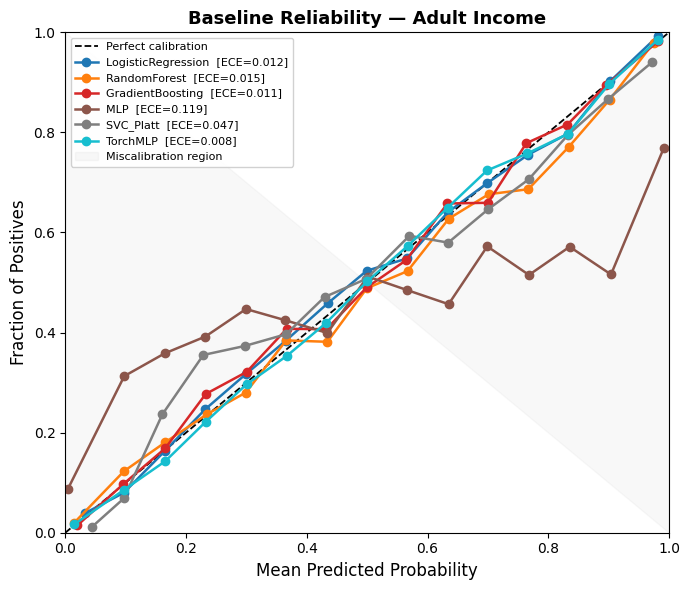

  Saved → calibration_outputs/Adult_Income_corrected.png


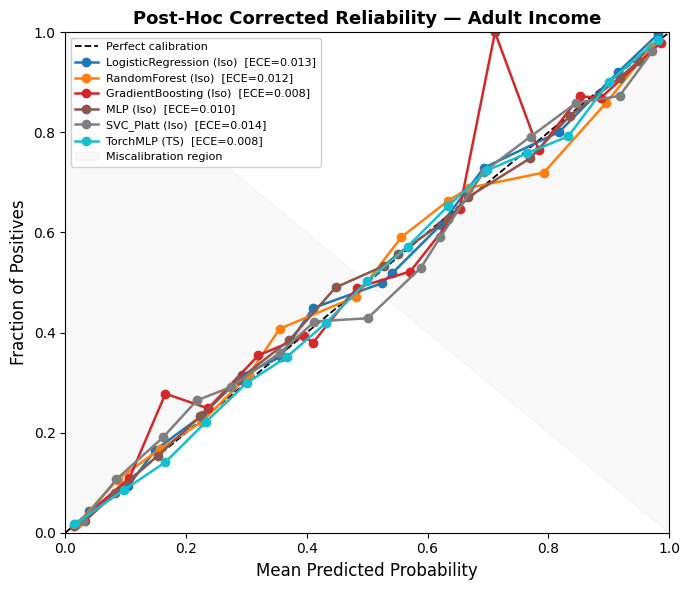


  Dataset: Adult Income  |  seed = 7

  ▶ LogisticRegression
    Baseline  ECE=0.0106  MCE=0.0579  AUC=0.8530
    Platt     ECE=0.0109  MCE=0.0593
    Isotonic  ECE=0.0169  MCE=0.0686

  ▶ RandomForest
    Baseline  ECE=0.0170  MCE=0.0848  AUC=0.9051
    Platt     ECE=0.0373  MCE=0.1378
    Isotonic  ECE=0.0102  MCE=0.0395

  ▶ GradientBoosting
    Baseline  ECE=0.0120  MCE=0.0342  AUC=0.9238
    Platt     ECE=0.0113  MCE=0.0476
    Isotonic  ECE=0.0098  MCE=0.0567

  ▶ MLP
    Baseline  ECE=0.1089  MCE=0.3146  AUC=0.8700
    Platt     ECE=0.0387  MCE=0.1524
    Isotonic  ECE=0.0109  MCE=0.0660

  ▶ SVC_Platt
    Baseline  ECE=0.0485  MCE=0.1066  AUC=0.8920
    Platt     ECE=0.0488  MCE=0.1108
    Isotonic  ECE=0.0082  MCE=0.0429

  ▶ TorchMLP + TemperatureScaling
    epoch 10/50 complete
    epoch 20/50 complete
    epoch 30/50 complete
    epoch 40/50 complete
    epoch 50/50 complete
    Baseline  ECE=0.0081  MCE=0.0310  AUC=0.9054
  Optimal temperature T = 1.0721
    TempScale ECE

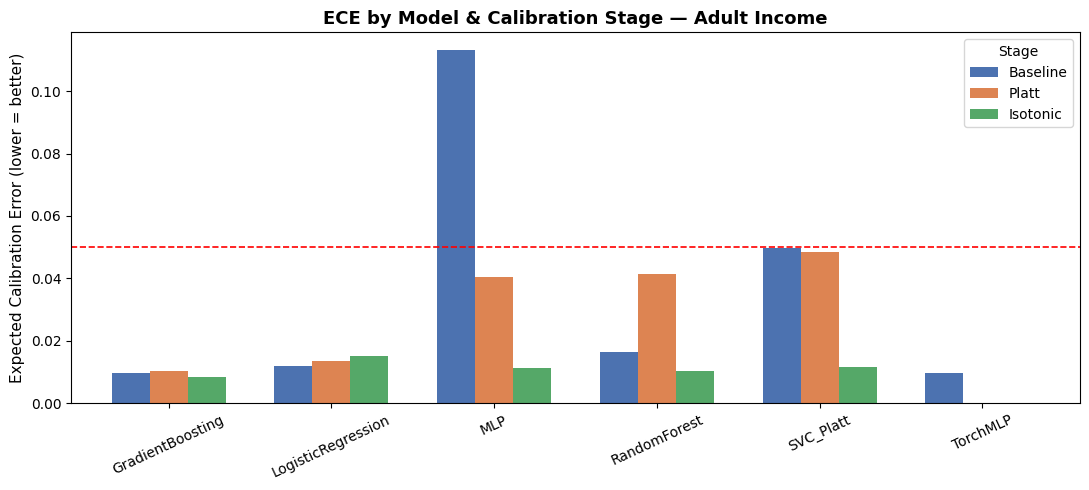

Loading Diabetes …
  768 samples | 8 features | positive rate = 0.349

  Dataset: Diabetes  |  seed = 42

  ▶ LogisticRegression
    Baseline  ECE=0.1147  MCE=0.2830  AUC=0.8368
    Platt     ECE=0.0899  MCE=0.3026
    Isotonic  ECE=0.0816  MCE=0.6505

  ▶ RandomForest
    Baseline  ECE=0.0742  MCE=0.2843  AUC=0.8349
    Platt     ECE=0.0777  MCE=0.1824
    Isotonic  ECE=0.0595  MCE=0.5000

  ▶ GradientBoosting
    Baseline  ECE=0.1724  MCE=0.4640  AUC=0.8244
    Platt     ECE=0.0942  MCE=0.2646
    Isotonic  ECE=0.0666  MCE=0.3773

  ▶ MLP
    Baseline  ECE=0.2415  MCE=0.5966  AUC=0.7687
    Platt     ECE=0.0561  MCE=0.1751
    Isotonic  ECE=0.0433  MCE=0.4625

  ▶ SVC_Platt
    Baseline  ECE=0.1010  MCE=0.3383  AUC=0.8203
    Platt     ECE=0.1101  MCE=0.3921
    Isotonic  ECE=0.0863  MCE=0.8501

  ▶ TorchMLP + TemperatureScaling
    epoch 10/50 complete
    epoch 20/50 complete
    epoch 30/50 complete
    epoch 40/50 complete
    epoch 50/50 complete
    Baseline  ECE=0.0813  MCE=0.

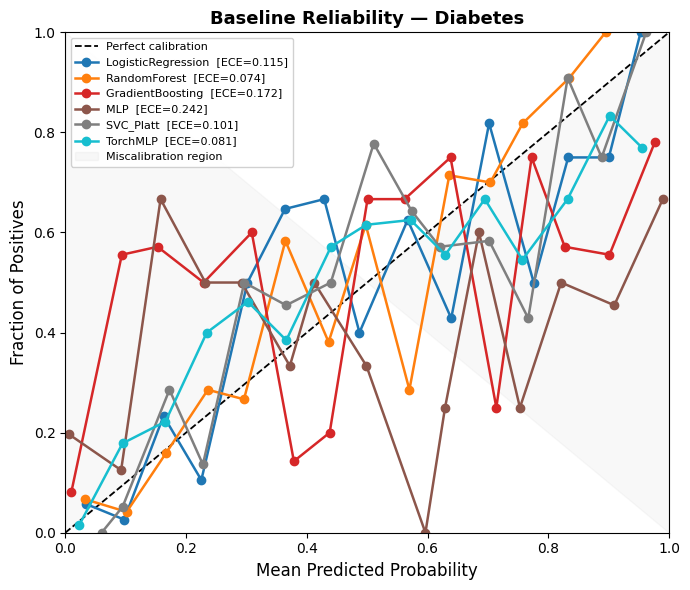

  Saved → calibration_outputs/Diabetes_corrected.png


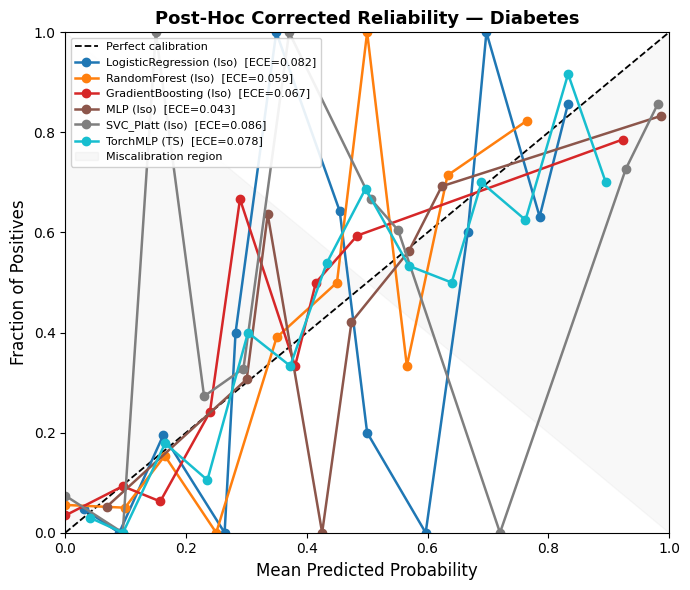


  Dataset: Diabetes  |  seed = 7

  ▶ LogisticRegression
    Baseline  ECE=0.0752  MCE=0.2274  AUC=0.8259
    Platt     ECE=0.1003  MCE=0.3198
    Isotonic  ECE=0.0751  MCE=0.2627

  ▶ RandomForest
    Baseline  ECE=0.0741  MCE=0.4450  AUC=0.8179
    Platt     ECE=0.0613  MCE=0.1547
    Isotonic  ECE=0.0955  MCE=0.6296

  ▶ GradientBoosting
    Baseline  ECE=0.1915  MCE=0.5749  AUC=0.8024
    Platt     ECE=0.1201  MCE=0.4107
    Isotonic  ECE=0.1045  MCE=0.4582

  ▶ MLP
    Baseline  ECE=0.1984  MCE=0.8020  AUC=0.8095
    Platt     ECE=0.0570  MCE=0.2307
    Isotonic  ECE=0.0598  MCE=0.3711

  ▶ SVC_Platt
    Baseline  ECE=0.0737  MCE=0.2435  AUC=0.8200
    Platt     ECE=0.0814  MCE=0.3779
    Isotonic  ECE=0.0911  MCE=0.3372

  ▶ TorchMLP + TemperatureScaling
    epoch 10/50 complete
    epoch 20/50 complete
    epoch 30/50 complete
    epoch 40/50 complete
    epoch 50/50 complete
    Baseline  ECE=0.0818  MCE=0.2089  AUC=0.8182
  Optimal temperature T = 1.2458
    TempScale ECE=0.0

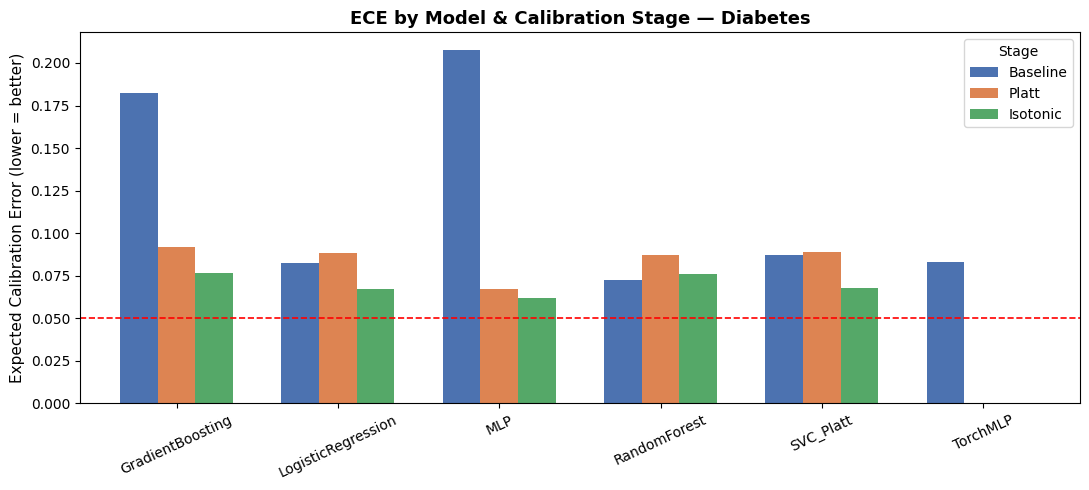


Full results CSV → calibration_outputs/all_binary_results.csv

  MNIST Multiclass Calibration
Loading MNIST …
  10000 train | 2000 test | 10 classes

  ▶ Logistic Regression (multiclass)
    Overall ECE = 0.0752

  ▶ TorchMLP (multiclass) + Temperature Scaling
    epoch 10/40 complete
    epoch 20/40 complete
    epoch 30/40 complete
    epoch 40/40 complete
    Baseline ECE = 0.0380
  Optimal temperature T = 2.3047
    After Temp-Scale ECE = 0.0128

  Per-class ECE comparison:
 Digit  Baseline ECE  TempScaled ECE
     0        0.0068          0.0050
     1        0.0049          0.0056
     2        0.0117          0.0084
     3        0.0128          0.0068
     4        0.0083          0.0040
     5        0.0103          0.0065
     6        0.0072          0.0067
     7        0.0114          0.0070
     8        0.0080          0.0064
     9        0.0092          0.0060

  Visually confusable digit pairs:
    (3,8)  Baseline=0.0549  TempScaled=0.0288
    (4,9)  Baseline=0.0467 

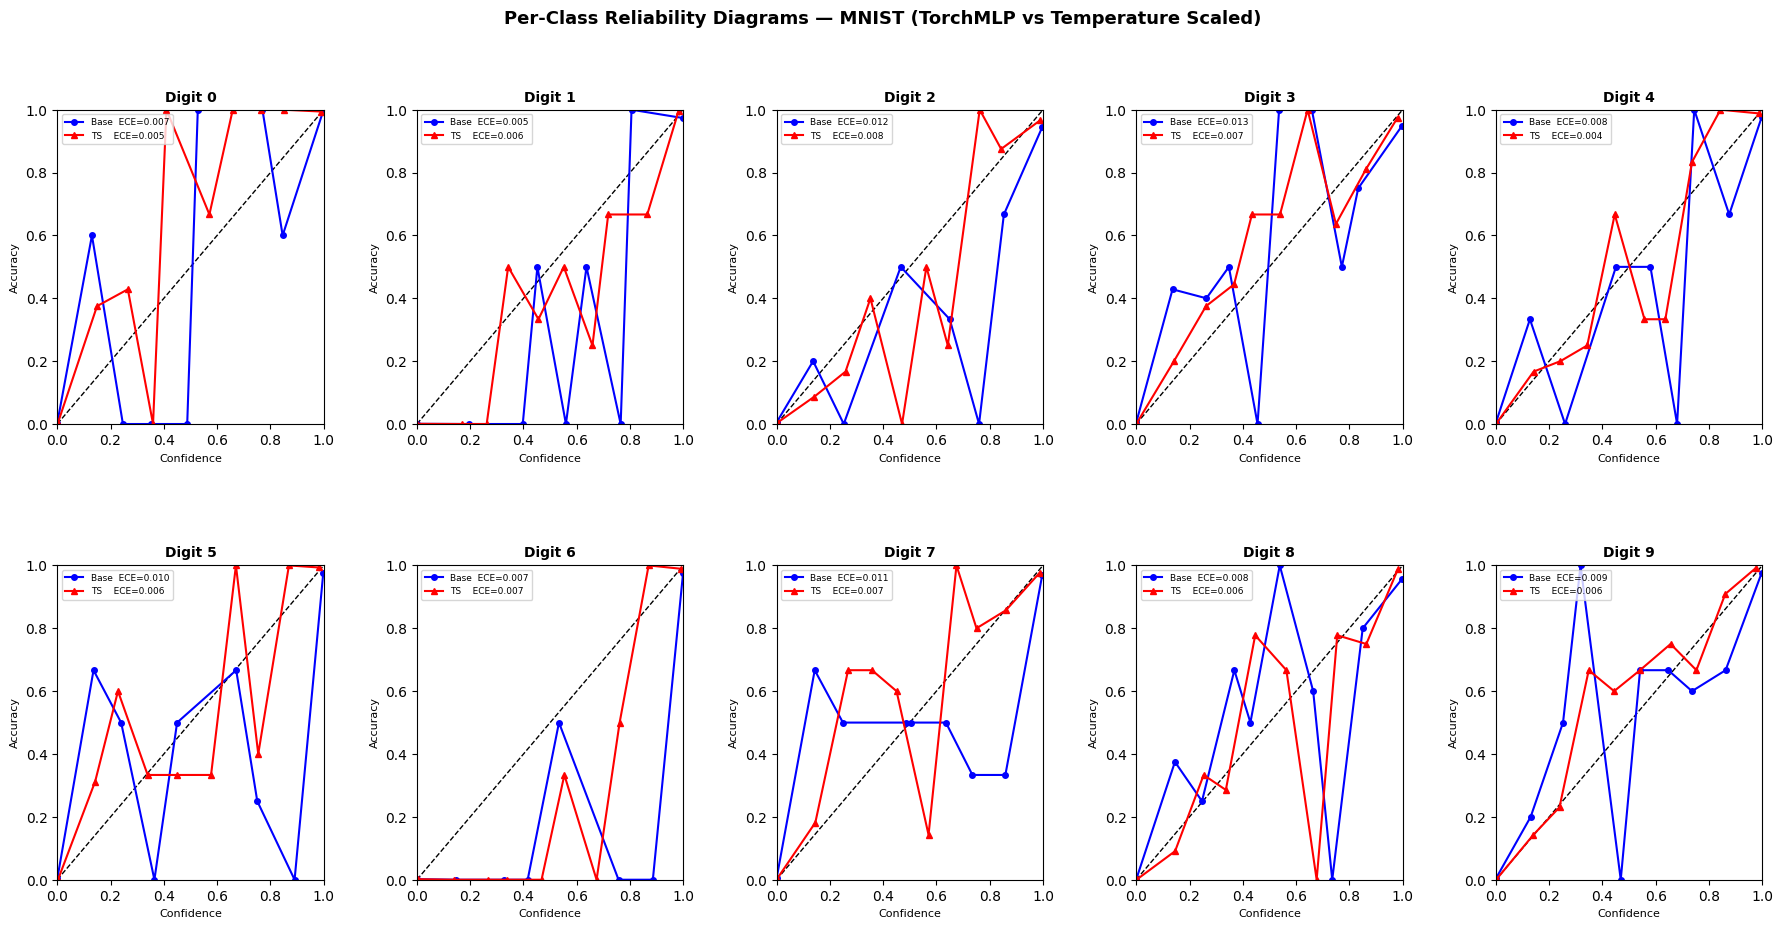

In [12]:
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

#  Adult Income 
X_adult, y_adult = load_adult()
df_adult, agg_adult = run_multiseed(X_adult, y_adult, "Adult Income")
plot_ece_comparison(df_adult, "Adult Income")
agg_adult.to_csv(OUTPUT_DIR / "adult_multiseed_summary.csv")

# Diabetes
X_diab, y_diab = load_diabetes()
df_diab, agg_diab = run_multiseed(X_diab, y_diab, "Diabetes")
plot_ece_comparison(df_diab, "Diabetes")
agg_diab.to_csv(OUTPUT_DIR / "diabetes_multiseed_summary.csv")

#  Save combined binary results 
all_binary = pd.concat([df_adult, df_diab], ignore_index=True)
all_binary.to_csv(OUTPUT_DIR / "all_binary_results.csv", index=False)
print(f"\nFull results CSV → {OUTPUT_DIR / 'all_binary_results.csv'}")

#  MNIST multiclass 
mnist_results = run_mnist_experiment()

## 13. Final Results Summary

In [13]:
for dataset in ["Adult Income", "Diabetes"]:
    print(f"\n  ── {dataset} (mean ECE across {len(SEEDS)} seeds) ──")
    sub   = all_binary[all_binary["Dataset"] == dataset]
    pivot = (sub.groupby(["Model", "Stage"])["ECE"]
             .mean()
             .unstack("Stage")
             .round(4))
    print(pivot.to_string())

print("\n  ── MNIST Multiclass ──")
for k, v in mnist_results.items():
    print(f"    {k}: {v:.4f}")

print(f"\n  all plots + CSVs written to → ./{OUTPUT_DIR}/")


████████████████████████████████████████████████████████████
  EXPERIMENT COMPLETE — Key Findings
████████████████████████████████████████████████████████████

  ── Adult Income (mean ECE across 5 seeds) ──
Stage               Baseline  Isotonic   Platt  TempScaling
Model                                                      
GradientBoosting      0.0098    0.0083  0.0104          NaN
LogisticRegression    0.0120    0.0150  0.0134          NaN
MLP                   0.1132    0.0113  0.0406          NaN
RandomForest          0.0163    0.0104  0.0414          NaN
SVC_Platt             0.0497    0.0116  0.0484          NaN
TorchMLP              0.0095       NaN     NaN       0.0094

  ── Diabetes (mean ECE across 5 seeds) ──
Stage               Baseline  Isotonic   Platt  TempScaling
Model                                                      
GradientBoosting      0.1821    0.0768  0.0916          NaN
LogisticRegression    0.0825    0.0669  0.0884          NaN
MLP                   0.2076